# Итоговый проект. Задача регрессии на Kaggle с помощью линейной регрессии

**Предсказание стоимости услуг репетитора**

В этом домашнем задании вам предстоит предсказать среднюю стоимость услуг репетитора за минуту (в рублях) на основе различных данных о нем. Вам будут доступны характеристики репетиторов: предмет преподавания, рейтинг, количество отзывов, описание опыта, образование и пр.

Вашей задачей будет построить модель, которая сможет предсказывать стоимость минутной консультации для новых репетиторов на основе предоставленной информации.

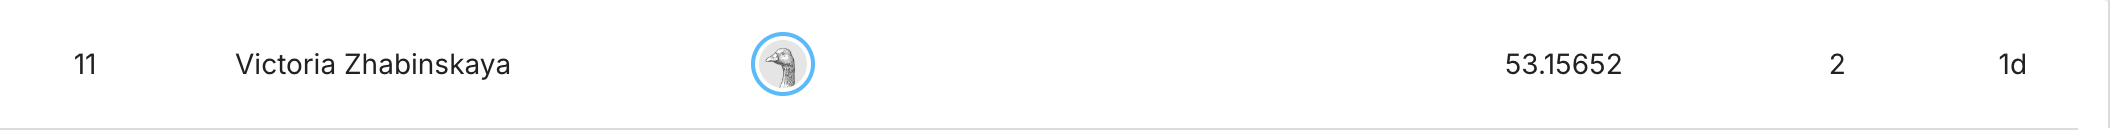

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import re
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings('ignore')

!pip install xgboost -q
!pip install lightgbm -q
!pip install catboost -q

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

## Исследование и анализ датасета
## Предобработка данных

Загружаем тренировочные и тестовые данные

In [ ]:
train_df = pd.read_excel('train.xlsx')
test_df = pd.read_excel('test.xlsx')

print(f"Обучающая выборка: {train_df.shape}")
print(f"Тестовая выборка: {test_df.shape}")

Обучающая выборка: (4548, 28)
Тестовая выборка: (1516, 27)


Обучающая выборка содержит 4548 строк и 28 столбцов, тестовая - 1516 строк и 27 столбцов. Посмотрим на столбцы

In [ ]:
train_df.columns.tolist()

['Unnamed: 0',
 'предмет',
 'ФИО',
 'tutor_head_tags',
 'tutor_rating',
 'tutor_reviews',
 'description',
 'experience_desc',
 'Education_1',
 'Desc_Education_1',
 'Education_2',
 'Desc_Education_2',
 'Education_3',
 'Desc_Education_3',
 'Education_4',
 'Desc_Education_4',
 'Ученая степень 1',
 'Ученое звание 1',
 'status',
 'experience',
 'Desc_Education_5',
 'Desc_Education_6',
 'Education_5',
 'Education_6',
 'Ученая степень 2',
 'Ученое звание 2',
 'categories',
 'mean_price']

Проверяем пропуски

In [ ]:
missing_train = train_df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_train / len(train_df) * 100).sort_values(ascending=False)
print("Пропуски в обучающей выборке:")
print(missing_percent[missing_percent > 0].head(15))

missing_test = test_df.isnull().sum().sort_values(ascending=False)
missing_percent_test = (missing_test / len(test_df) * 100).sort_values(ascending=False)
print("\nПропуски в тестовой выборке:")
print(missing_percent_test[missing_percent_test > 0].head(15))

Пропуски в обучающей выборке:
Education_6         99.978012
Ученое звание 2     99.978012
Ученая степень 2    99.978012
Desc_Education_6    99.978012
Desc_Education_5    99.934037
Education_5         99.934037
Desc_Education_4    99.648197
Education_4         99.648197
Ученое звание 1     99.230431
Ученая степень 1    98.328936
Desc_Education_3    97.691293
Education_3         97.669305
Desc_Education_2    82.915567
Education_2         82.827617
experience_desc     52.264732
dtype: float64

Пропуски в тестовой выборке:
Ученое звание 2     100.000000
Education_6         100.000000
Desc_Education_6    100.000000
Ученая степень 2     99.934037
Education_5          99.934037
Desc_Education_5     99.934037
Desc_Education_4     99.802111
Education_4          99.802111
Ученое звание 1      99.538259
Ученая степень 1     98.680739
Desc_Education_3     97.757256
Education_3          97.757256
Desc_Education_2     81.200528
Education_2          81.134565
experience_desc      50.065963
dtype: flo

В данных много колонок с более 80% пропусков, их можно удалить. А также столбец 'Unnamed: 0' и ФИО

In [ ]:
cols_to_drop = []
for col in train_df.columns:
    if train_df[col].isnull().sum() / len(train_df) > 0.8:
        cols_to_drop.append(col)

print(f"Колонки для удаления: {cols_to_drop}")

train_df_clean = train_df.drop(columns=cols_to_drop)
test_df_clean = test_df.drop(columns=[col for col in cols_to_drop if col in test_df.columns])

Колонки для удаления: ['Education_2', 'Desc_Education_2', 'Education_3', 'Desc_Education_3', 'Education_4', 'Desc_Education_4', 'Ученая степень 1', 'Ученое звание 1', 'Desc_Education_5', 'Desc_Education_6', 'Education_5', 'Education_6', 'Ученая степень 2', 'Ученое звание 2']


In [ ]:
train_df_clean = train_df_clean.drop(columns=['Unnamed: 0', 'ФИО'])
test_df_clean = test_df_clean.drop(columns=['Unnamed: 0', 'ФИО'])

Заполняем пропуски в числовых признаках медианой.

In [ ]:
numeric_cols = train_df_clean.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'mean_price']

for col in numeric_cols:
    if train_df_clean[col].isnull().any():
        median_val = train_df_clean[col].median()
        train_df_clean[col].fillna(median_val, inplace=True)
        if col in test_df_clean.columns:
            test_df_clean[col].fillna(median_val, inplace=True)

Заполняем пропуски в категориальных признаках модой.

In [ ]:
categorical_cols = train_df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if train_df_clean[col].isnull().any():
        mode_val = train_df_clean[col].mode()[0] if not train_df_clean[col].mode().empty else 'Не указано'
        train_df_clean[col].fillna(mode_val, inplace=True)
        if col in test_df_clean.columns:
            test_df_clean[col].fillna(mode_val, inplace=True)

Проверяем пропуски

In [ ]:
print("Остались ли пропуски в train:", train_df_clean.isnull().sum().sum())
print("Остались ли пропуски в test:", test_df_clean.isnull().sum().sum())

Остались ли пропуски в train: 0
Остались ли пропуски в test: 0


**Вывод:** Обучающая выборка включает 4548 записей и 28 признаков, тестовая — 1516 записей и 27 признаков. Ключевые поля включают предмет преподавания, рейтинг, количество отзывов, описание опыта, образование и другие характеристики. При анализе были выявлены значительные пропуски в данных, особенно в колонках, связанных с образованием и учеными степенями, где процент пропусков превышает 80%. Это потребовало проведения тщательной предобработки данных. На этапе предобработки были удалены колонки с более чем 80% пропусков, а также технические столбцы, такие как 'Unnamed: 0' и 'ФИО', которые не несут полезной информации для моделирования. Пропуски в числовых признаках были заполнены медианными значениями, а в категориальных — наиболее частыми значениями (модой). В результате все пропуски были успешно устранены, что обеспечило целостность данных для дальнейшего анализа и обучения моделей.


## Feature Engineering

Создаём новые признаки: длина описания, количество слов, опыт в годах, количество указанных образований.

In [ ]:
def extract_text_features(df):
    df = df.copy()

    if 'description' in df.columns:
        df['description_length'] = df['description'].apply(lambda x: len(str(x)))
        df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))

    if 'experience_desc' in df.columns:
        df['experience_desc_length'] = df['experience_desc'].apply(lambda x: len(str(x)))
        df['has_experience_desc'] = df['experience_desc'].apply(lambda x: 1 if str(x).strip() not in ['', 'nan', 'Не указано'] else 0)

    if 'experience' in df.columns:
        def extract_years(exp):
            exp_str = str(exp)
            patterns = [
                r'(\d+)\s*год[ау]?',
                r'(\d+)\s*лет',
                r'(\d+)\+',
                r'(\d+)\s*г\.'
            ]

            for pattern in patterns:
                matches = re.findall(pattern, exp_str.lower())
                if matches:
                    try:
                        return float(matches[0])
                    except:
                        continue
            return 0

        df['years_experience'] = df['experience'].apply(extract_years)
        df['has_experience_info'] = df['experience'].apply(lambda x: 1 if str(x).strip() not in ['', 'nan', 'Не указано'] else 0)

    education_cols = [col for col in df.columns if 'Education_' in col and col != 'Desc_Education_1']
    df['education_count'] = df[education_cols].apply(lambda row: sum(pd.notnull(row)), axis=1)

    return df

train_df_fe = extract_text_features(train_df_clean)
test_df_fe = extract_text_features(test_df_clean)

print(f"Новые признаки в train: {train_df_fe.shape}")
print(f"Новые признаки в test: {test_df_fe.shape}")

Новые признаки в train: (4548, 19)
Новые признаки в test: (1516, 18)


Создано 6 новых признаков, что увеличило размерность данных. Кодируем категориальные признаки: LabelEncoder для признаков с высокой кардинальностью, OneHotEncoding — для низкой.

In [ ]:
X_train = train_df_fe.drop(columns=['mean_price'])
y_train = train_df_fe['mean_price']
X_test = test_df_fe.copy()

categorical_cols = X_train.select_dtypes(include=['object']).columns

small_cardinality_cols = []
for col in categorical_cols:
    if X_train[col].nunique() <= 10:
        small_cardinality_cols.append(col)

for col in categorical_cols:
    if col not in small_cardinality_cols:
        le = LabelEncoder()
        combined = pd.concat([X_train[col], X_test[col]], axis=0)
        le.fit(combined.astype(str))
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

X_train_encoded = pd.get_dummies(X_train, columns=small_cardinality_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=small_cardinality_cols, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"После кодирования: X_train shape = {X_train_encoded.shape}, X_test shape = {X_test_encoded.shape}")

После кодирования: X_train shape = (4548, 26), X_test shape = (1516, 26)


**Вывод:** Для улучшения качества данных и повышения информативности признаков были созданы новые признаки: длина описания репетитора и количество слов в нём, длина описания опыта и индикатор наличия такого описания, опыт работы в годах, извлечённый из текстового поля, количество указанных образований.

## Подбор признаков, их анализ и оценка важности

Масштабируем числовые признаки

In [ ]:
scaler = StandardScaler()
numeric_cols = X_train_encoded.select_dtypes(include=['int64', 'float64']).columns

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

Используем Mutual Information для выбора наиболее информативных признаков.

In [ ]:
selector = SelectKBest(score_func=mutual_info_regression, k=50)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
selected_indices = selector.get_support(indices=True)
selected_cols = X_train_scaled.columns[selected_indices]

print(f"Отобрано {len(selected_cols)} признаков с помощью mutual information")
print("\nТоп-10 признаков по mutual information:")
scores = selector.scores_
feature_scores = list(zip(X_train_scaled.columns, scores))
feature_scores.sort(key=lambda x: x[1], reverse=True)
for col, score in feature_scores[:10]:
    print(f"{col}: {score:.4f}")

X_train_final = pd.DataFrame(X_train_selected, columns=selected_cols)
X_test_final = X_test_scaled[selected_cols]

Отобрано 26 признаков с помощью mutual information

Топ-10 признаков по mutual information:
Desc_Education_1: 0.7872
description: 0.6944
Education_1: 0.6775
description_length: 0.6459
experience_desc: 0.5516
experience_desc_length: 0.5224
description_word_count: 0.5103
categories: 0.3965
years_experience: 0.2968
experience: 0.2749


**Вывод:** Для выбора наиболее информативных признаков использовался метод Mutual Information, который оценивает взаимосвязь между признаками и целевой переменной. Были отобраны 26 наиболее значимых признаков. Наибольшую важность показали такие признаки, как описание образования, длина описания репетитора и опыт работы. Это указывает на то, что именно эти характеристики сильнее всего влияют на стоимость услуг репетитора. Признаки были масштабированы для использования в моделях, требующих нормализации данных.

## Обучение нескольких моделей, их сравнение

In [ ]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42
)

print(f"Train: {X_train_split.shape}, Val: {X_val_split.shape}")

Train: (3638, 26), Val: (910, 26)


Обучаем 7 разных моделей регрессии:
- Linear Regression
- Decision Tree
- Random Tree
- Gradient Boosting
- KNN
- XGBoost
- CatBoost

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN': KNeighborsRegressor(n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

results = []
for name, model in models.items():
    model.fit(X_train_split, y_train_split)
    y_pred = model.predict(X_val_split)

    mae = mean_absolute_error(y_val_split, y_pred)
    mse = mean_squared_error(y_val_split, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val_split, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

    print(f"  {name}:")
    print(f"    MAE: {mae:.4f}")
    print(f"    MSE: {mse:.4f}")
    print(f"    RMSE: {rmse:.4f}")
    print(f"    R2: {r2:.4f}")
    print()

  Linear Regression:
    MAE: 6.7737
    MSE: 97.8881
    RMSE: 9.8938
    R2: 0.1703

  Decision Tree:
    MAE: 8.0247
    MSE: 139.0714
    RMSE: 11.7929
    R2: -0.1787

  Random Forest:
    MAE: 6.0343
    MSE: 93.3096
    RMSE: 9.6597
    R2: 0.2091

  Gradient Boosting:
    MAE: 6.3339
    MSE: 93.2223
    RMSE: 9.6552
    R2: 0.2099

  KNN:
    MAE: 6.7516
    MSE: 108.1069
    RMSE: 10.3974
    R2: 0.0837

  XGBoost:
    MAE: 6.4015
    MSE: 97.1359
    RMSE: 9.8558
    R2: 0.1767

  CatBoost:
    MAE: 6.1325
    MSE: 91.5292
    RMSE: 9.5671
    R2: 0.2242



In [ ]:
results_df = pd.DataFrame(results)
print("Сравнение моделей (сортировка по MSE):")
print(results_df.sort_values('MSE', ascending=True).to_string(index=False))
print()

Сравнение моделей (сортировка по MSE):
            Model      MAE        MSE      RMSE        R2
         CatBoost 6.132533  91.529167  9.567088  0.224235
Gradient Boosting 6.333873  93.222327  9.655171  0.209885
    Random Forest 6.034251  93.309568  9.659688  0.209145
          XGBoost 6.401489  97.135895  9.855754  0.176715
Linear Regression 6.773658  97.888143  9.893844  0.170339
              KNN 6.751582 108.106916 10.397448  0.083729
    Decision Tree 8.024722 139.071389 11.792853 -0.178714



CatBoost показал наилучшие результаты по MSE

**Вывод:** Было обучено 7 различных моделей регрессии, включая линейную регрессию, Decision Tree, случайный лес, градиентный бустинг, метод ближайших соседей (KNN), XGBoost и CatBoost. Модели оценивались по метрикам MAE, MSE, RMSE и R². Наилучшие результаты показали CatBoost (MSE = 91.53) и Random Forest (MSE = 93.31), в то время как Decision Tree показала наихудшие результаты (MSE = 139.07).



## Подбор гиперпараметров

Используем RandomizedSearchCV для подбора гиперпараметров для 6 моделей.

In [ ]:
param_grids = {
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    },
    'CatBoost': {
        'iterations': [100, 200, 300],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5]
    }
}

best_models = {}
best_scores = {}

In [ ]:
print("\nЛинейная регрессия (без подбора гиперпараметров):")
lr_model = LinearRegression()
lr_model.fit(X_train_split, y_train_split)
y_pred_lr = lr_model.predict(X_val_split)
mse_lr = mean_squared_error(y_val_split, y_pred_lr)
best_models['Linear Regression'] = lr_model
best_scores['Linear Regression'] = mse_lr
print(f"   MSE: {mse_lr:.4f}")

for model_name, model in models.items():
    if model_name !=  'Linear Regression':
        print(f"\n{model_name}:")

        if model_name in param_grids:
            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grids[model_name],
                n_iter=20,
                cv=3,
                scoring='neg_mean_squared_error',
                random_state=42,
                n_jobs=-1,
                verbose=0
            )

            random_search.fit(X_train_split, y_train_split)

            best_models[model_name] = random_search.best_estimator_
            best_scores[model_name] = -random_search.best_score_

            print(f"   Лучшие параметры: {random_search.best_params_}")
            print(f"   Лучший MSE: {-random_search.best_score_:.4f}")




Линейная регрессия (без подбора гиперпараметров):
   MSE: 97.8881

Decision Tree:
   Лучшие параметры: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5}
   Лучший MSE: 95.3765

Random Forest:
   Лучшие параметры: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
   Лучший MSE: 82.9851

Gradient Boosting:
   Лучшие параметры: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}
   Лучший MSE: 83.2882

KNN:
   Лучшие параметры: {'weights': 'distance', 'n_neighbors': 11, 'algorithm': 'ball_tree'}
   Лучший MSE: 89.5806

XGBoost:
   Лучшие параметры: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
   Лучший MSE: 82.3592

CatBoost:
   Лучшие параметры: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 8}
   Лучший MSE: 83.2694


**Вывод:** Для улучшения качества моделей был проведён подбор гиперпараметров с использованием RandomizedSearchCV. Наилучший результат после оптимизации показал XGBoost с MSE = 82.36, что улучшило его исходный результат. Подбор гиперпараметров позволил существенно снизить ошибку моделей, особенно для XGBoost, Random Forest и CatBoost, подтвердив важность тонкой настройки параметров для достижения высокой точности.

## Выбор лучшей модели и объяснение выбора

Выбираем модель с наименьшим MSE после подбора гиперпараметров.

In [ ]:
best_scores_df = pd.DataFrame({
    'Model': list(best_scores.keys()),
    'MSE': list(best_scores.values())
}).sort_values('MSE', ascending=True)

print(best_scores_df.to_string(index=False))

best_model_name = best_scores_df.iloc[0]['Model']
best_model = best_models[best_model_name]
best_mse = best_scores_df.iloc[0]['MSE']

print(f"Лучшая модель: {best_model_name} с MSE = {best_mse:.4f}")

            Model       MSE
          XGBoost 82.359198
    Random Forest 82.985112
         CatBoost 83.269424
Gradient Boosting 83.288172
              KNN 89.580647
    Decision Tree 95.376498
Linear Regression 97.888143
Лучшая модель: XGBoost с MSE = 82.3592


**Вывод:** Лучшей моделью был выбран XGBoost, так как он показал наименьшее значение MSE (82.36) после подбора гиперпараметров.

## Предсказание на тестовых данных


Обучаем лучшую модель на всём тренировочном наборе и делаем предсказание на тесте. Предсказания сохраняем в submission.csv.

In [ ]:
best_model.fit(X_train_final, y_train)

y_test_pred = best_model.predict(X_test_final)

submission = pd.DataFrame({
    'index': test_df['Unnamed: 0'].values,
    'mean_price': y_test_pred
})

submission_file = 'submission.csv'
submission.to_csv(submission_file, index=False)


**Вывод:** Лучшая модель (XGBoost) была обучена на полном тренировочном наборе данных, после чего выполнено предсказание на тестовой выборке. Результаты предсказаний сохранены в файл submission.csv, который содержит идентификаторы записей и предсказанные значения средней стоимости услуг репетитора.